In [24]:
import hoda
import tensorly as tl
import mne

mne.set_log_level('ERROR')
tl.get_backend()

'cupy'

In [25]:
from moabb.paradigms import P300, MotorImagery
from moabb.datasets import *
from mne.decoding import Scaler

paradigm = P300(resample=64)
dataset = BNCI2014009()


epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[1],
                                         return_epochs=True)
session = meta['session'][0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]

epochs._data = Scaler(scalings='mean', with_mean=True).fit_transform(epochs._data)

BNCI2014009 has been renamed to BNCI2014_009. BNCI2014009 will be removed in version 1.1.
The dataset class name 'BNCI2014009' must be an abbreviation of its code 'BNCI2014-009'. See moabb.datasets.base.is_abbrev for more information.


In [26]:
meta

,subject,session,run
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0
...,...,...,...
571,1,0,0
572,1,0,0
573,1,0,0
574,1,0,0


In [27]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl
import numpy as np

nfreqs=16

X = epochs.get_data()
"""
tensor =  STFTensor(sfreq=sfreq, tmin=tmin,
            morlet_params=dict(freqs=np.linspace(fmin, fmax, nfreqs)),
            baseline_params=dict(baseline=(-.15,-.05), mode='logratio'),
            decim=8
)

X = tensor.fit_transform(X)
"""
y = labels

X.shape

(576, 16, 52)

In [49]:
from hoda.hoda import BTTDA, HODA, trunc_eigh
from hoda.cov import mode_scatter


bttda = BTTDA(
    ranks=[None]*16,
    hoda_params=dict(
        rank=None,
        max_iter=256,
        tol=1e-12,
        init ='random',
        shrinkage='lw',
        toeplitz=None,
        obj='rt',
        solver='lanczos',
        taper=True,
        extra_train_info=False,
        verbose=True,
        delta=0.1,
        ortho=False,
        forward=False,
        random_state=42,
       
    ),
    verbose=True,
    extra_train_info=True,
)
#%env PYTHONWARNINGS=ignore
%lprun -f HODA.fit_forward bttda.fit(X,y)

Fitting block 1/16...


  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

Fitting block 2/16...


  0%|          | 0/256 [00:00<?, ?it/s]

...

  0%|          | 0/256 [00:00<?, ?it/s]

Fitting block 16/16...


  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

Timer unit: 1e-09 s

Total time: 0.683812 s
File: /project/src/hoda/hoda.py
Function: fit_forward at line 327

Line #      Hits         Time  Per Hit   % Time  Line Contents
   327                                               def fit_forward(self, X, y, Xt=None):
   328                                                   # TODO: add regularization
   329                                                   # Convert to tensor
   330        16      87339.0   5458.7      0.0          if not tl.is_tensor(X):
   331                                                       X = tl.tensor(X)
   332        16      33713.0   2107.1      0.0          n_samples, *shape = X.shape
   333        16       6205.0    387.8      0.0          order = len(shape)
   334                                           
   335                                                   # Project
   336        16       5378.0    336.1      0.0          if Xt is None:
   337        16    9119217.0 569951.1      1.3              Xt =

In [50]:
import pandas as pd
df = pd.DataFrame(bttda.train_info_)
df

,block,rank,mse,F_tr,F_rt
0,1,"(3, 3)",0.999919,0.327149,0.009850
1,2,"(3, 3)",0.999879,0.334748,0.009577
2,3,"(3, 3)",0.999853,0.342657,0.009679
3,4,"(3, 3)",0.999833,0.350048,0.009744
4,5,"(3, 3)",0.999814,0.356856,0.009796
5,6,"(3, 3)",0.999797,0.363147,0.009840
6,7,"(4, 4)",0.999787,0.357919,0.011136
7,8,"(3, 3)",0.999771,0.363956,0.011193
8,9,"(4, 4)",0.999760,0.358103,0.011364
9,10,"(3, 3)",0.999745,0.363910,0.011413


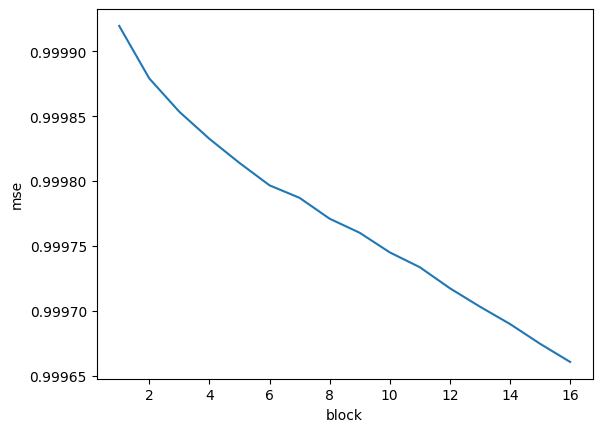

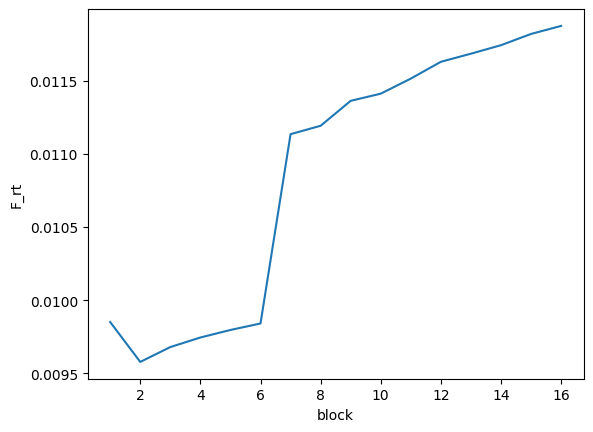

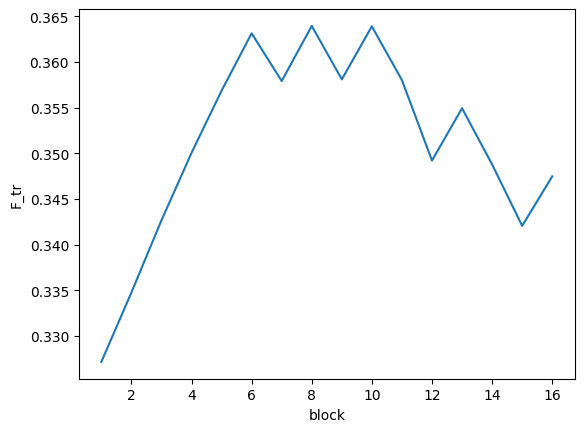

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('default')
if bttda.extra_train_info:
    n_samples = X.shape[0]
    sns.lineplot(data=df, x='block', y='mse')
    plt.show()
    sns.lineplot(data=df,x='block',y='F_rt')
    plt.show()
    sns.lineplot(data=df,x='block',y='F_tr')

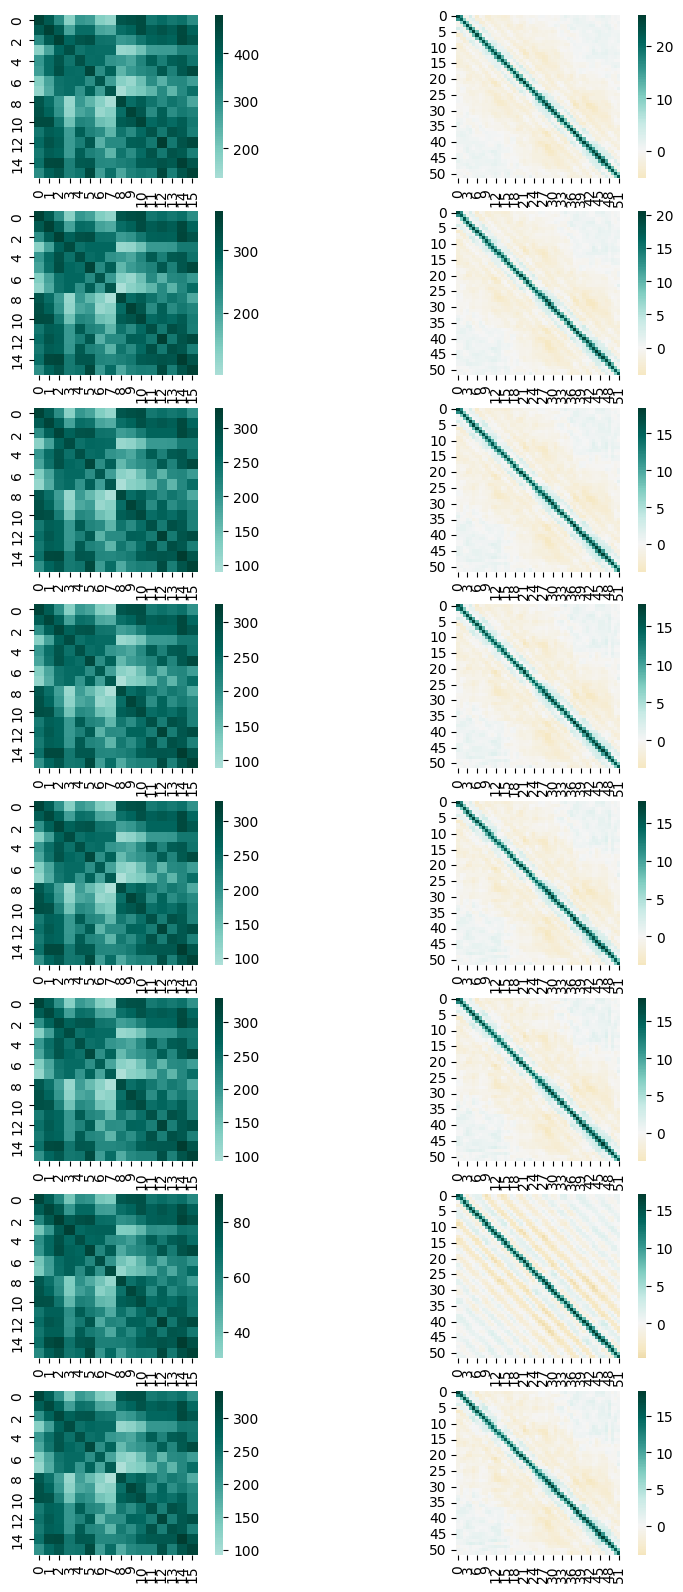

In [40]:
fig, axs = plt.subplots(min(bttda.n_blocks_,8),2, figsize=(10,20))
for b in range(min(bttda.n_blocks_,8)):
    for k in range(2):
        scatter = bttda.blocks_[b].scatter_w_[k]
        scatter = tl.to_numpy(scatter)
        sns.heatmap(scatter, ax=axs[b,k], square=True, center=0, cmap='BrBG')

In [41]:
Xt = bttda.transform(X)

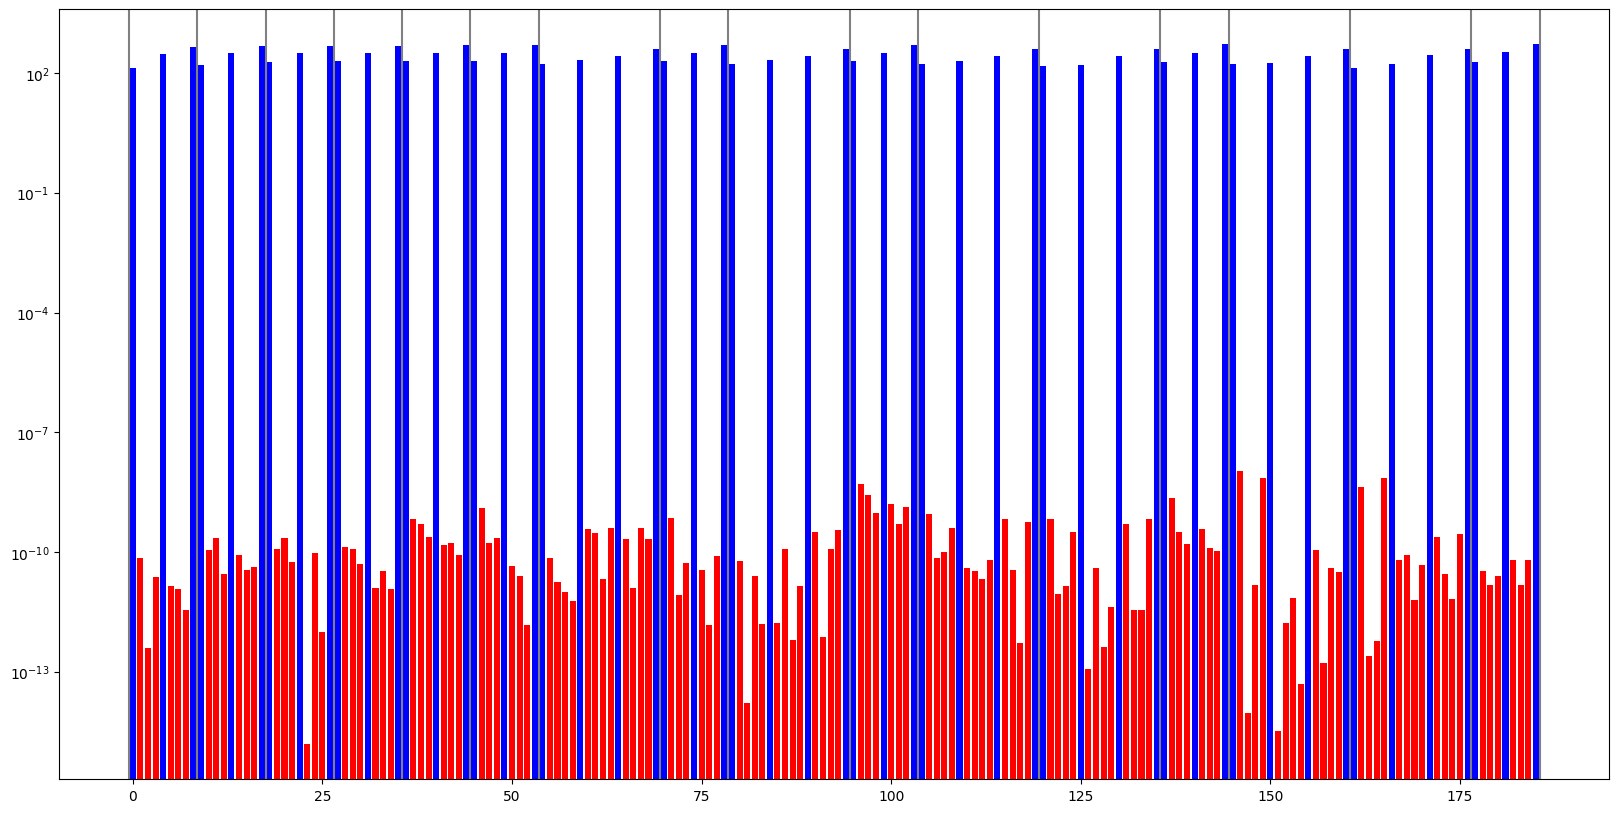

In [42]:
import scipy.stats
import seaborn as sns
import math
import numpy as np

samples = []
for c in bttda.blocks_[0].classes_:
    samples.append(tl.to_numpy(Xt)[y==c])
F,p = scipy.stats.f_oneway(*samples, axis=0)
F = F.flatten()
p = p.flatten()
p = np.nan_to_num(p, nan=1)

alpha=0.5
sig_idc = p < alpha

fig, ax = plt.subplots(1,1, figsize=(20,10))
ax.bar(np.arange(len(F))[sig_idc],F[sig_idc], color='blue')
ax.bar(np.arange(len(F))[~sig_idc],F[~sig_idc], color='red')
ax.set_yscale('log')
n_params=0
ax.axvline(n_params-.5, color='grey')
for b in bttda.blocks_:
    n_params+=math.prod(b.rank_)
    ax.axvline(n_params-.5, color='grey')


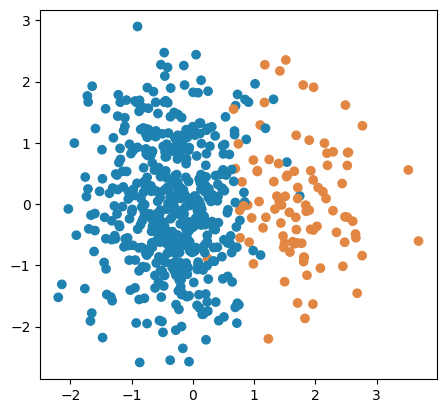

In [43]:
from sklearn.manifold import TSNE
import math
from sklearn.decomposition import PCA
import re, seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap

if Xt.shape[-1] > 1:
    n_components = 2
    decomp  = PCA(n_components=n_components, whiten=True)
    Xt_viz = decomp.fit_transform(tl.to_numpy(Xt[:,sig_idc]))
    
    cmap = {'Target': '#e28743', 'NonTarget': '#1e81b0'}
    c = np.vectorize(cmap.get)(y)    
    fig, ax = plt.subplots(1,1)
    ax.scatter(Xt_viz[:,0], Xt_viz[:,1], c=c)
    ax.set_aspect('equal')


In [44]:
 import numpy as np

evokeds = []
vmax=0
for cls in np.unique(labels):
    evoked = epochs[cls].average()
    evokeds.append(evoked)
    vmax= max(vmax, np.max(np.abs(evoked.data))*1.2*1e6)

ts_args=dict(ylim=dict(eeg=[-vmax,vmax]))
joint_args=dict(ts_args=ts_args)

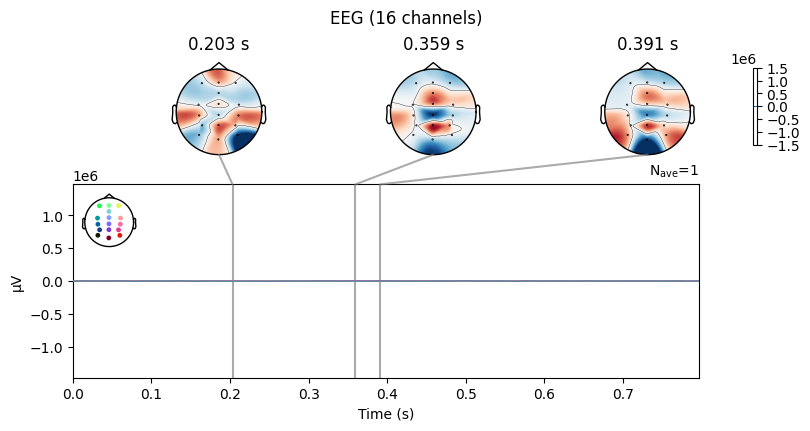

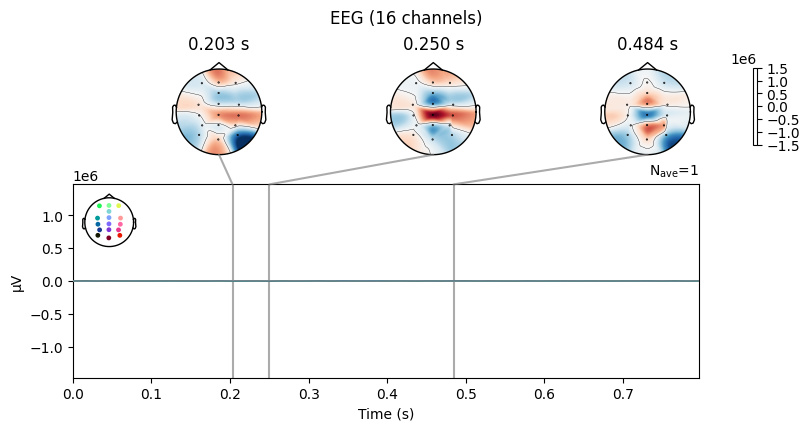

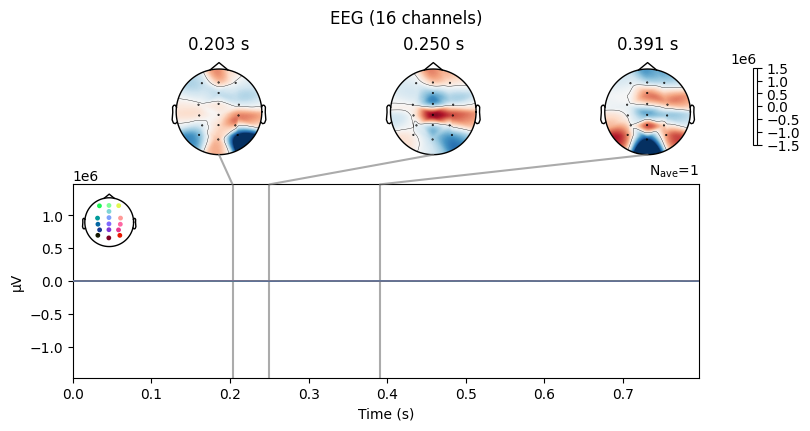

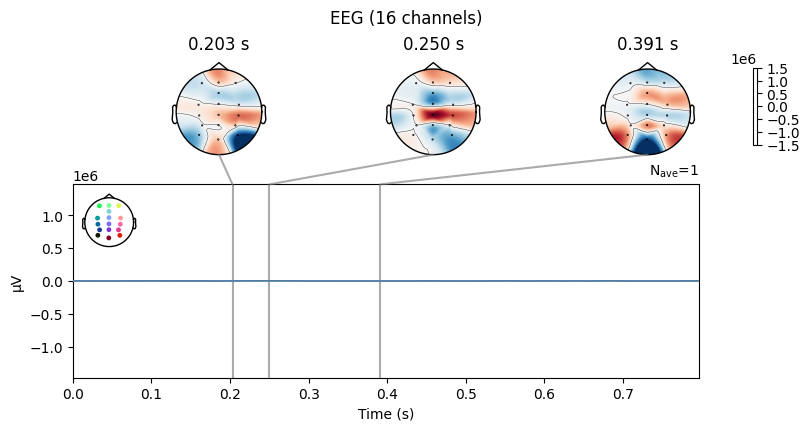

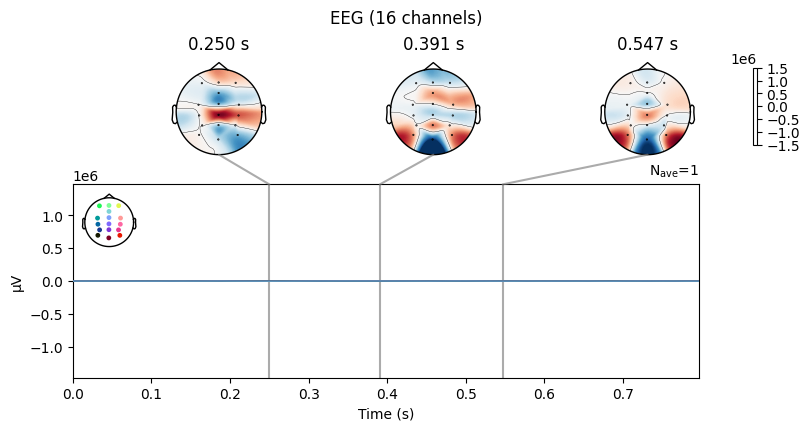

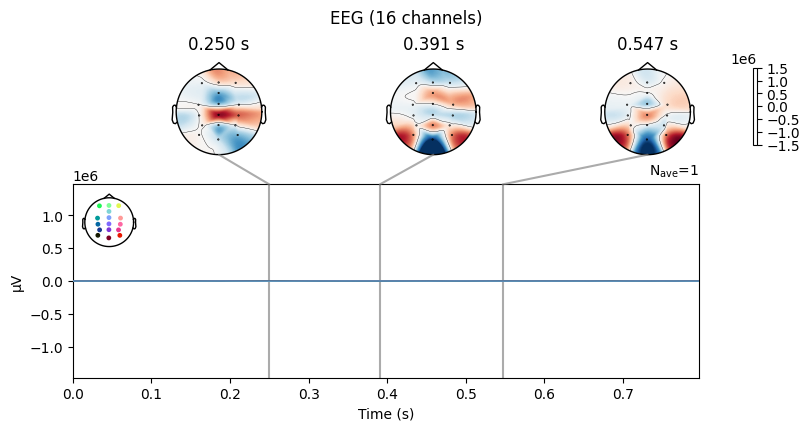

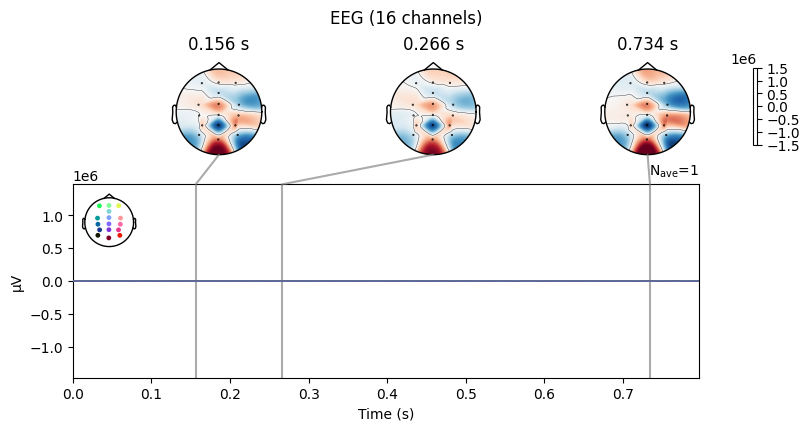

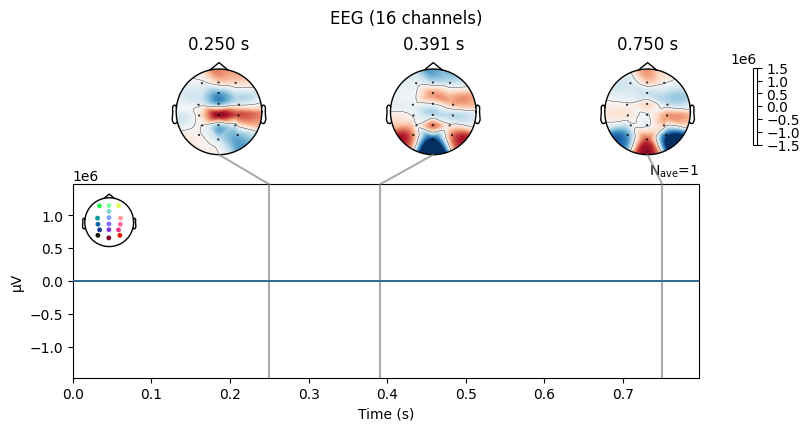

In [45]:
from mne import EvokedArray
for b in bttda.blocks_[:8]:
    means_rec = b.inv_transform(b.transform(b.means_))
    contrast = means_rec[1]-means_rec[0]
    contrast = EvokedArray(tl.to_numpy(contrast), epochs.info, epochs.tmin)
    contrast.plot_joint(**joint_args)